# Documentación de Análisis: Clasificación de Alimentos mediante Machine Learning

Este cuaderno presenta un flujo de trabajo avanzado para la segmentación de aditivos alimentarios basándose en perfiles de riesgo toxicológico y nutricional, utilizando datos integrados de Open Food Facts y PubMed.

### 1. Configuración del Entorno y Librerías
El análisis utiliza el stack estándar de Python para ciencia de datos y aprendizaje no supervisado:
* **Tratamiento de datos**: `pandas` y `numpy`.
* **Visualización**: `matplotlib`, `seaborn` y `plotly.express` para gráficos interactivos.
* **Machine Learning (Scikit-Learn)**:
    * `StandardScaler`: Para normalizar las escalas de las variables de toxicidad.
    * `PCA`: Para reducción de dimensionalidad y visualización en 2D.
    * `KMeans`: Algoritmo principal de agrupamiento.
    * `silhouette_score`: Para validar la calidad de los clusters.

### 2. Preprocesamiento: Estandarización y PCA
Se aplica un análisis de **Componentes Principales (PCA)** sobre las dimensiones de riesgo (Cargas de Clase 0, 1 y 2) y el grado de procesamiento (NOVA):
* **Normalización**: Debido a que las cargas de aditivos pueden tener magnitudes muy diferentes, se utiliza `StandardScaler` para que ninguna variable domine injustamente el modelo.
* **Visualización de Dimensiones**: El Biplot de PCA permite observar cómo los aditivos se distribuyen en el espacio. Las flechas rojas (vectores de carga) indican qué riesgos científicos "empujan" a los aditivos hacia zonas de mayor peligro en el mapa.

### 3. Optimización del Agrupamiento (K-Means)
Para determinar la estructura óptima de los grupos, se utilizan dos técnicas:
* **Método del Codo (Elbow Method)**: Evalúa la reducción de la inercia (error cuadrático interno) a medida que aumenta el número de clusters ($K$). Ayuda a identificar el "punto de ruptura" donde añadir más grupos no aporta una mejora significativa.
* **Análisis de Silhouette**: Mide qué tan cerca está cada punto de su propio cluster en comparación con los demás. Un valor promedio alto (cercano a 1) indica que el agrupamiento es natural y los grupos están bien separados.

### 4. Perfilado de Clusters (Heatmap)
Tras ejecutar K-Means, se genera un **Mapa de Calor** basado en las medias de cada variable por cluster:
* **Diagnóstico de Riesgo**: Permite etiquetar los grupos según su perfil (ej: "Aditivos Críticos", "Uso Seguro", "Falsos Amigos").
* **Relación NOVA-Química**: El mapa revela correlaciones importantes, como el hecho de que productos altamente procesados (NOVA 4) suelen concentrar una mayor carga de aditivos Clase 2 (riesgo alto).

### 5. Generación de la Taxonomía Final
Finalmente, el cuaderno exporta una **Taxonomía de Riesgo** vinculada a los identificadores originales (`codigo_e`, `id` de Open Food Facts)[cite: 1, 4]. Esto permite que el análisis científico basado en PubMed se aplique directamente a la base de datos de productos reales, facilitando la identificación de alimentos problemáticos para el consumidor final.

In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos y visualización
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Machine Learning: Preprocesamiento y Reducción de dimensiones
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Machine Learning: Clustering y Evaluación
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

### 3. Optimización del Agrupamiento (K-Means)
Para determinar la estructura óptima de los grupos, se utilizan dos técnicas:
* **Método del Codo (Elbow Method)**: Evalúa la reducción de la inercia (error cuadrático interno) a medida que aumenta el número de clusters ($K$). Ayuda a identificar el "punto de ruptura" donde añadir más grupos no aporta una mejora significativa.
* **Análisis de Silhouette**: Mide qué tan cerca está cada punto de su propio cluster en comparación con los demás. Un valor promedio alto (cercano a 1) indica que el agrupamiento es natural y los grupos están bien separados.

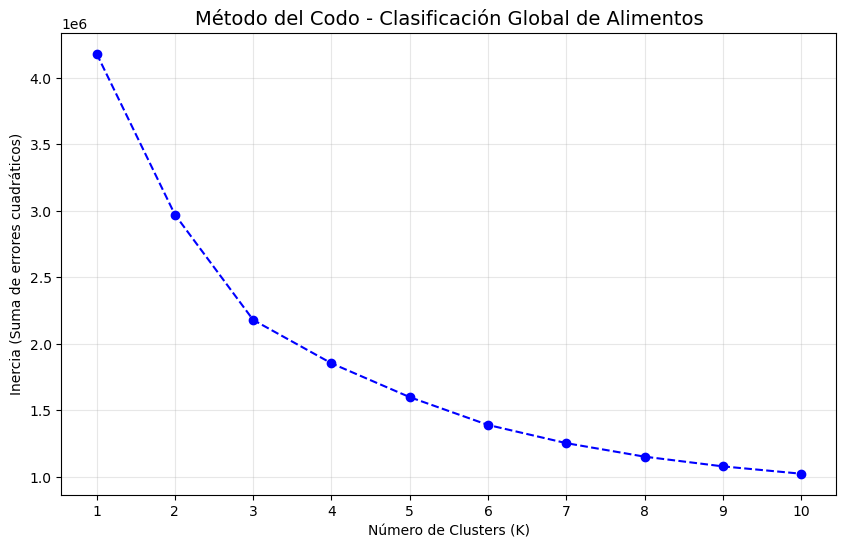

Inercia para K=2: 2971248.19
Inercia para K=3: 2179360.78
Inercia para K=4: 1853270.52
Inercia para K=5: 1598869.37


In [7]:
# 1. Cargar el dataset de alimentos procesado (el que unifica 800k registros)
df_final = pd.read_csv('../data/dataset_alimentos_quimica_nutricion.csv')

# 2. Seleccionar las características maestras para el clustering
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1', 'carga_clase_2']
X = df_final[features]

# 3. Preprocesamiento: Estandarización
# Nivelamos el peso de todas las variables para que el modelo no se sesgue por las magnitudes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Calcular la inercia para el Método del Codo (Elbow Method)
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 5. Visualización del Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo - Clasificación Global de Alimentos', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/plots/food_products/metodo_codo_alimentos.png')
plt.show()

# 6. Salida de datos para análisis técnico
print(f"Inercia para K=2: {inertia[1]:.2f}")
print(f"Inercia para K=3: {inertia[2]:.2f}")
print(f"Inercia para K=4: {inertia[3]:.2f}")
print(f"Inercia para K=5: {inertia[4]:.2f}")

Para K = 3, el promedio de silhouette es: 0.3522


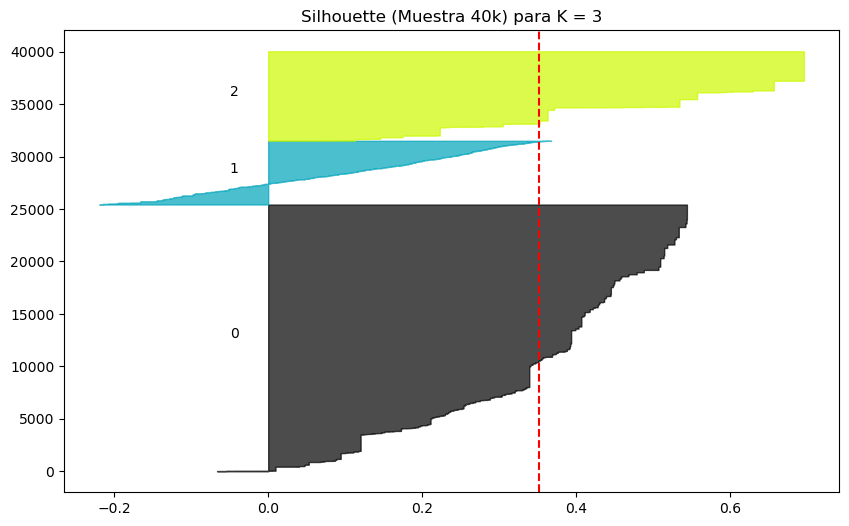

Para K = 4, el promedio de silhouette es: 0.3038


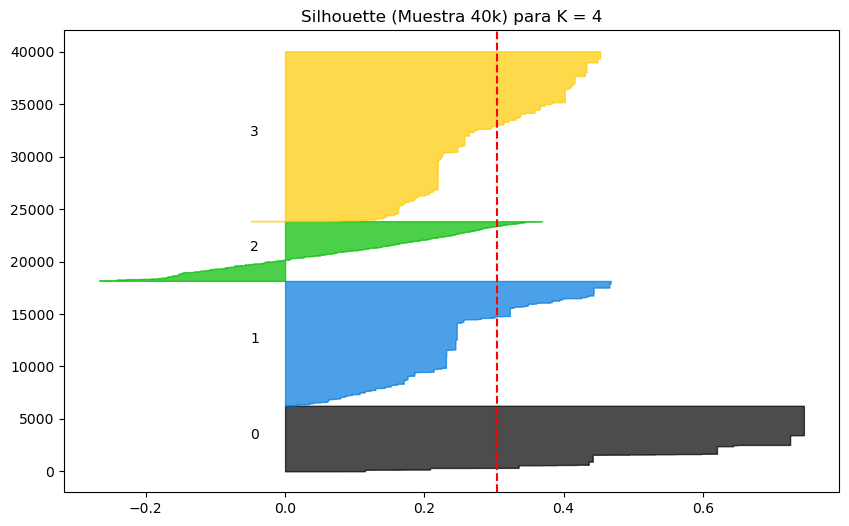

Para K = 5, el promedio de silhouette es: 0.3104


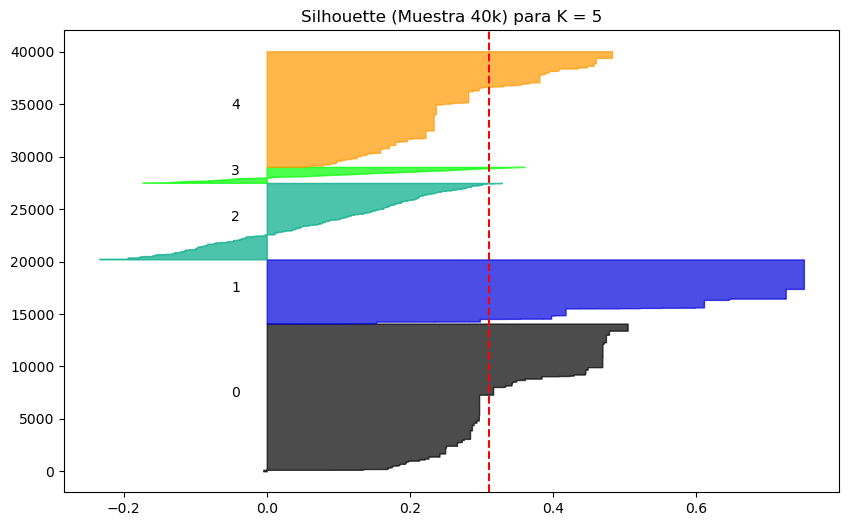

In [9]:
# 1. Cargar y estandarizar

df_sample = df_final.sample(n=40000, random_state=42)
X_sample = StandardScaler().fit_transform(df_sample[features])

for n_clusters in [3, 4, 5]:
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 6)

    # Entrenamos el auditor solo con la muestra
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_sample)

    silhouette_avg = silhouette_score(X_sample, cluster_labels)
    print(f"Para K = {n_clusters}, el promedio de silhouette es: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_sample, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, 
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title(f"Silhouette (Muestra 40k) para K = {n_clusters}")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.savefig(f'../outputs/plots/food_products/silhouette_{n_clusters}_clusters.png')
    plt.show()

### 4. Perfilado de Clusters (Heatmap)
Tras ejecutar K-Means, se genera un **Mapa de Calor** basado en las medias de cada variable por cluster:
* **Diagnóstico de Riesgo**: Permite etiquetar los grupos según su perfil (ej: "Aditivos Críticos", "Uso Seguro", "Falsos Amigos").
* **Relación NOVA-Química**: El mapa revela correlaciones importantes, como el hecho de que productos altamente procesados (NOVA 4) suelen concentrar una mayor carga de aditivos Clase 2 (riesgo alto).

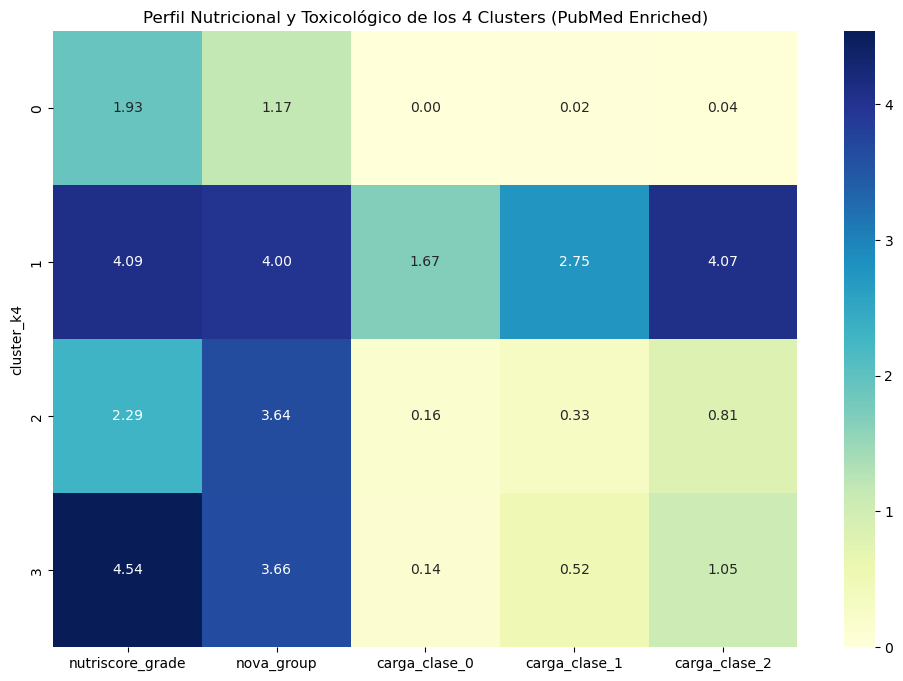

            nutriscore_grade  nova_group  carga_clase_0  carga_clase_1  \
cluster_k4                                                               
0                       1.93        1.17           0.00           0.02   
1                       4.09        4.00           1.67           2.75   
2                       2.29        3.64           0.16           0.33   
3                       4.54        3.66           0.14           0.52   

            carga_clase_2  
cluster_k4                 
0                    0.04  
1                    4.07  
2                    0.81  
3                    1.05  


In [10]:
# 1. Selección de variables y escalado
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1', 'carga_clase_2']
X = df_final[features].fillna(0) # Por si quedó algún nulo

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Ejecutar K-Means con la K ganadora (4)
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster_k4'] = kmeans_4.fit_predict(X_scaled)

# 3. Generar la tabla de medias
tabla_medias_k4 = df_final.groupby('cluster_k4')[features].mean().round(2)

# 4. Visualización para el informe
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_medias_k4, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Perfil Nutricional y Toxicológico de los 4 Clusters (PubMed Enriched)')
plt.savefig('../outputs/plots/food_products/matriz.png')
plt.show()

print(tabla_medias_k4)

In [11]:
# 1. Comprobación rápida: ¿Hay datos en las columnas de carga?
print("Suma de cargas antes del heatmap:")
print(df_final[['carga_clase_0', 'carga_clase_1', 'carga_clase_2']].sum())

# 2. Si el paso anterior da números grandes, el problema es el escalado.
# Si el paso anterior da 0, es que el DataFrame se ha 'reseteado' y hay que volver a correr
# el bloque de 'Vinculación directa por nombre de columna' que funcionó antes.

Suma de cargas antes del heatmap:
carga_clase_0     287478
carga_clase_1     586687
carga_clase_2    1048069
dtype: int64


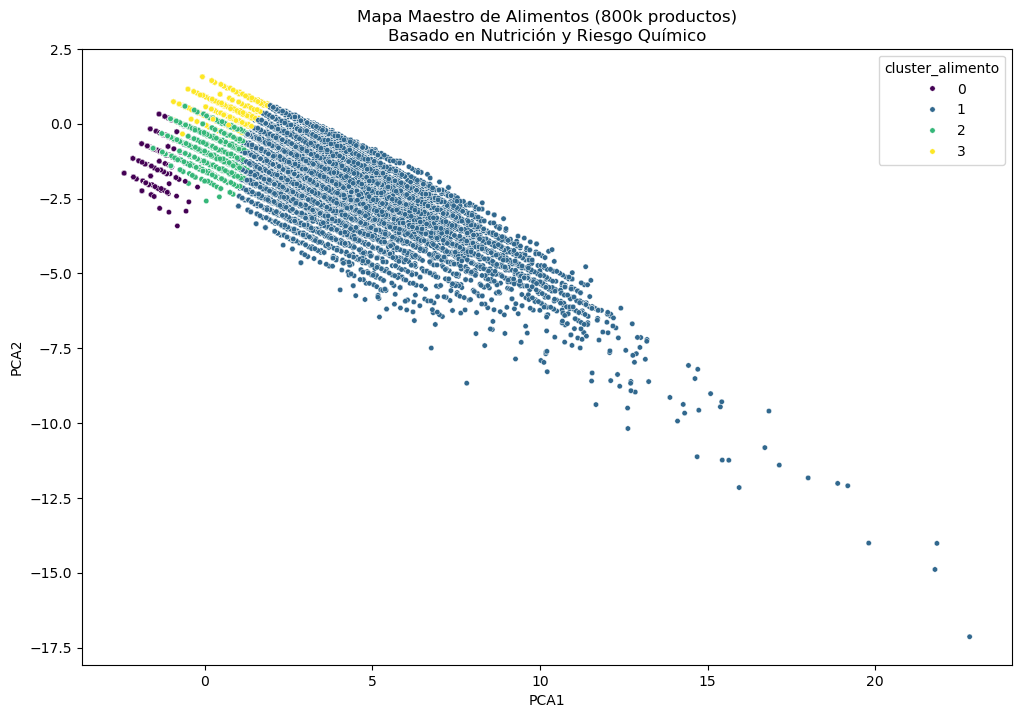

TABLA DE PERFILADO:
                  nutriscore_grade  nova_group  carga_clase_0  carga_clase_1  \
cluster_alimento                                                               
0                         1.932933    1.172339       0.003560       0.017426   
1                         4.093246    3.998583       1.674318       2.745113   
2                         2.286976    3.637585       0.156989       0.332633   
3                         4.540891    3.664659       0.143315       0.516265   

                  carga_clase_2  
cluster_alimento                 
0                      0.037800  
1                      4.074157  
2                      0.811432  
3                      1.053093  


In [ ]:
# 1. Preparar datos finales
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1', 'carga_clase_2']
X_scaled = StandardScaler().fit_transform(df_final[features])

# 2. Ejecutar K-Means con el K=4 que elegimos
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster_alimento'] = kmeans.fit_predict(X_scaled)

# 3. PCA para visualizar la "geografía" del mercado
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)
df_final['PCA1'] = pca_res[:, 0]
df_final['PCA2'] = pca_res[:, 1]

plt.figure(figsize=(12, 8))
# Usamos un alpha bajo porque hay 800k puntos y se solaparán
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_alimento', data=df_final, 
                palette='viridis', alpha=1, s=15)

plt.title('Mapa Maestro de Alimentos (800k productos)\nBasado en Nutrición y Riesgo Químico')
plt.savefig('../outputs/plots/food_products/PCA_final_alimentos.png')
plt.show()

# 4. EXPLICACIÓN DE LOS GRUPOS 
perfil = df_final.groupby('cluster_alimento')[features].mean()
print("TABLA DE PERFILADO:")
print(perfil)

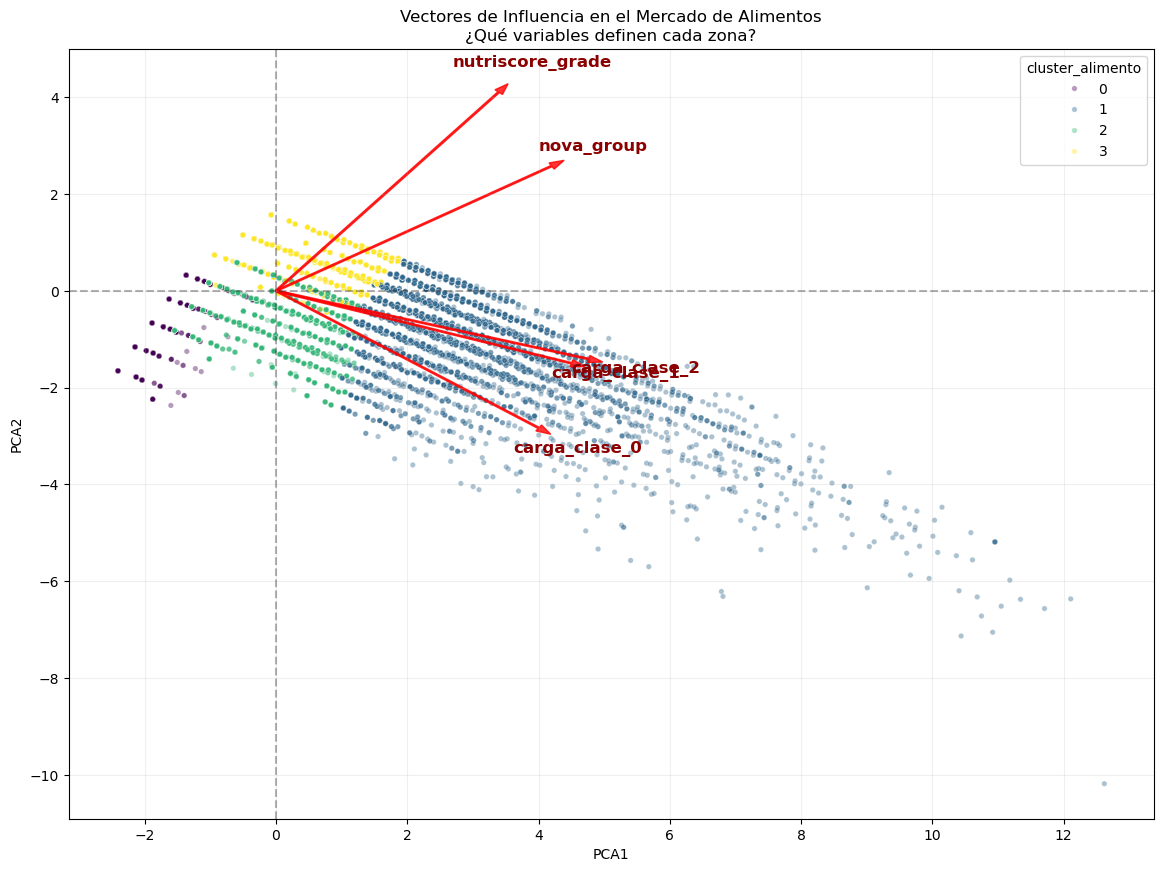

In [14]:
#Obtener los loadings (la importancia de cada variable en los ejes PCA)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(14, 10))

# Dibujamos los puntos (usamos una muestra de 50k para que las flechas resalten)
df_plot = df_final.sample(n=50000, random_state=42)
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_alimento', data=df_plot, 
                palette='viridis', alpha=0.4, s=15)

#Añadir las flechas (Vectores)
# Ajustamos scale_factor para que las flechas tengan un tamaño legible en el gráfico
scale_factor = 6 

for i, feature in enumerate(features):
    # Dibujar la flecha
    plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, 
              color='red', alpha=0.8, width=0.03, head_width=0.15)
    
    # Añadir el nombre de la variable
    plt.text(loadings[i, 0] * scale_factor * 1.15, loadings[i, 1] * scale_factor * 1.15, 
             feature, color='darkred', ha='center', va='center', fontweight='bold', fontsize=12)

plt.title('Vectores de Influencia en el Mercado de Alimentos\n¿Qué variables definen cada zona?')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(alpha=0.2)
plt.savefig('../outputs/plots/food_products/PCA_vectores_alimentos.png')
plt.show()

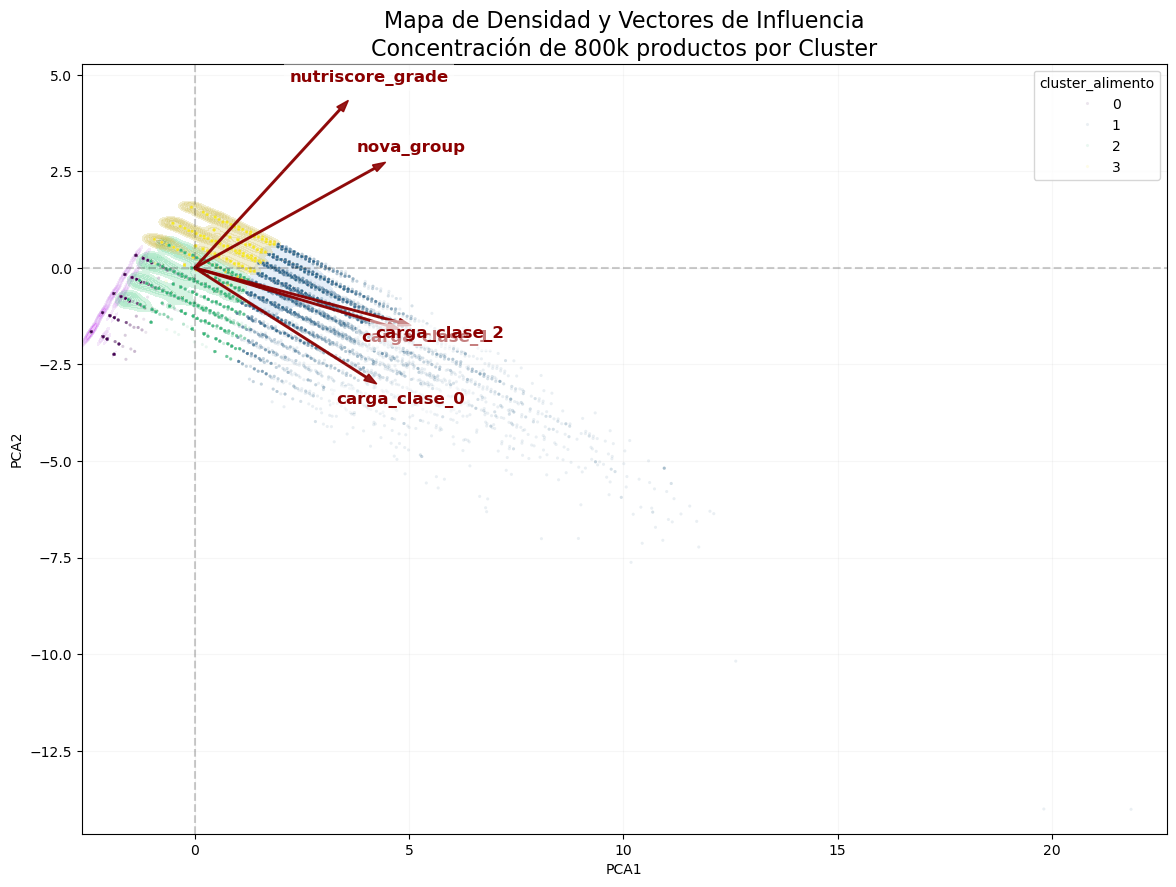

In [15]:
# 1. Configuración del lienzo
plt.figure(figsize=(14, 10))

# 2. Dibujar la densidad (el gradiente de transparencia)
# Usamos una muestra mayor (100k) para que el gradiente sea preciso pero rápido
df_density = df_final.sample(n=100000, random_state=42)

# El truco: kdeplot con niveles de transparencia
sns.kdeplot(
    data=df_density, x='PCA1', y='PCA2', 
    hue='cluster_alimento', palette='viridis',
    fill=True, alpha=0.3, levels=10, thresh=0.05,
    legend=False
)

# 3. Dibujamos los puntos con alpha muy bajo para dar textura sin tapar
sns.scatterplot(
    x='PCA1', y='PCA2', hue='cluster_alimento', data=df_density, 
    palette='viridis', alpha=0.1, s=5, legend='full'
)

# 4. Añadir las flechas (Loadings del PCA)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
scale_factor = 6 

for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, 
              color='darkred', alpha=0.9, width=0.04, head_width=0.2)
    
    plt.text(loadings[i, 0] * scale_factor * 1.2, loadings[i, 1] * scale_factor * 1.2, 
             feature, color='darkred', ha='center', va='center', 
             fontweight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# 5. Estética final
plt.title('Mapa de Densidad y Vectores de Influencia\nConcentración de 800k productos por Cluster', fontsize=16)
plt.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.axvline(0, color='black', linestyle='--', alpha=0.2)
plt.grid(alpha=0.1)
plt.savefig('../outputs/plots/food_products/PCA_vectores_densidad_alimentos.png')
plt.show()

In [16]:
# 1. Preparar datos y escalado
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1', 'carga_clase_2']
X_scaled = StandardScaler().fit_transform(df_final[features])

# 2. PCA para 3 componentes
pca = PCA(n_components=3)
pca_res = pca.fit_transform(X_scaled)
df_final['PCA1'] = pca_res[:, 0]
df_final['PCA2'] = pca_res[:, 1]
df_final['PCA3'] = pca_res[:, 2]

# 3. Tomar una muestra para que el gráfico sea fluido al girarlo
# 30,000 puntos es el "punto dulce" entre detalle y rendimiento
df_interactivo = df_final.sample(n=80000, random_state=42)

# 4. Crear el gráfico 3D INTERACTIVO
fig = px.scatter_3d(
    df_interactivo, 
    x='PCA1', 
    y='PCA2', 
    z='PCA3',
    color='cluster_alimento',  # Los colores de tus 4 grupos
    title='Mapa Maestro Interactivo 3D: Gira con el ratón',
    labels={'cluster_alimento': 'Cluster'},
    opacity=0.7,
    color_continuous_scale='Viridis'
)

# Ajustar el tamaño de los puntos
fig.update_traces(marker=dict(size=2))

# 5. ¡A girar!
fig.show()

Distribución de los 800k alimentos por Cluster:
---------------------------------------------
Cluster 0:  130899 alimentos (15.65%)
Cluster 1:  119233 alimentos (14.26%)
Cluster 2:  247603 alimentos (29.61%)
Cluster 3:  338464 alimentos (40.48%)


/tmp/ipykernel_304087/4203096234.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_clusters.index, y=conteo_clusters.values, palette='viridis')


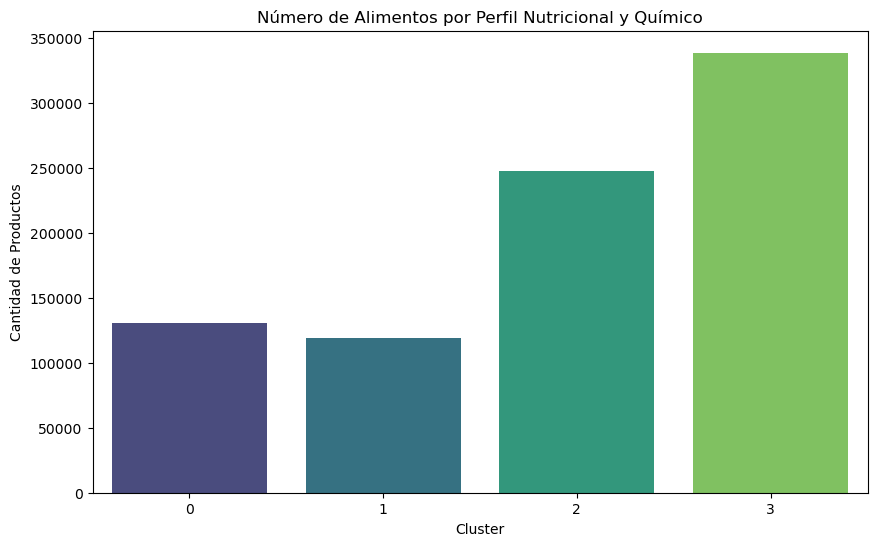

In [17]:
# 1. Realizar el conteo
conteo_clusters = df_final['cluster_alimento'].value_counts().sort_index()

# 2. Mostrar los resultados numéricos
print("Distribución de los 800k alimentos por Cluster:")
print("-" * 45)
for cluster, total in conteo_clusters.items():
    porcentaje = (total / len(df_final)) * 100
    print(f"Cluster {cluster}: {total:>7} alimentos ({porcentaje:>5.2f}%)")

# 3. Visualización rápida
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_clusters.index, y=conteo_clusters.values, palette='viridis')
plt.title('Número de Alimentos por Perfil Nutricional y Químico')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de Productos')
plt.show()

In [18]:
def perfilado_binario_falsos_amigos(row):
    # Identificamos el Cluster Verde (Cluster 2) según tu PCA
    if row['cluster_alimento'] == 2:
        # Si tiene CUALQUIER aditivo que no sea de Clase 0, va a Alerta
        if (row['carga_clase_1'] > 0) or (row['carga_clase_2'] > 0):
            return "Falso Amigo - Perfil de Riesgo"
        else:
            return "Falso Amigo - Perfil Seguro"
    
    # Mantenemos el resto de pilares igual
    mapping_nombres = {
        0: "Alimento Saludable (Morado)",
        3: "Calórico pero honesto (Amarillo)",
        1: "Calórico y Sucio (Azul)"
    }
    
    return mapping_nombres.get(row['cluster_alimento'], f"Cluster {row['cluster_alimento']}")

# Aplicar la nueva lógica
df_final['categoria_final'] = df_final.apply(perfilado_binario_falsos_amigos, axis=1)

# Ver el nuevo conteo
print(df_final['categoria_final'].value_counts())

categoria_final
Calórico pero honesto (Amarillo)    338464
Falso Amigo - Perfil de Riesgo      133601
Alimento Saludable (Morado)         130899
Calórico y Sucio (Azul)             119233
Falso Amigo - Perfil Seguro         114002
Name: count, dtype: int64
